In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

In [3]:
tf.version.VERSION

'2.8.0'

In [4]:
# Bildgrößen und Pfad definieren
IMAGE_SIZE = (128, 128)
IMAGE_DIRECTORY = "use_these_images"

In [33]:
# Funktion zum Einlesen der Bilder und Labels
def load_images_from_directory(directory):
    images = []
    labels = []

    for filename in os.listdir(directory):
        if filename.endswith('.jpg'):
          # label = filename.split('_')[1].split(".")[0]
          label = filename.split("_")[4].split(".")[0]
        else:
          continue

        label = float(label)

        img = cv2.imread(os.path.join(directory, filename))

        img_crop = img[150:350,:,:]
        # img_blur = cv2.blur(img_crop,(5, 5))
        # img_hsv = cv2.cvtColor(img_blur, cv2.COLOR_BGR2HSV)
        # lower_blue = np.array([94, 40, 100])
        # upper_blue = np.array([132, 255, 255])
        # mask = cv2.inRange(img_hsv, lower_blue, upper_blue)
        # edges = cv2.Canny(mask, 50, 150, apertureSize=3)

        
        # # ERSTMAL wieder zurück in BGR-Raum
        # img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        img = cv2.resize(img_crop, IMAGE_SIZE)
        img = img / 255.0

        images.append(img)
        labels.append(label)

        # images.append(img[:,::-1])
        images.append(img[:,::-1,:])
        labels.append(180-label)

    # # hier einmal die Spiegelung der bestehenden Bilder
    # for i in range(len(images)):
    #    images.append(images[i][:,::-1,:])
    #    labels.append(180-labels[i])
      
    return np.array(images), np.array(labels)

In [7]:
def plot_train_history(history):
  plt.plot(history.history['loss'], color='blue')
  plt.plot(history.history['val_loss'], color='red')
  plt.legend(["training loss", "validation loss"])

In [34]:
# Bilder und Labels laden
images, labels = load_images_from_directory(IMAGE_DIRECTORY)

labels

array([ 58., 122.,  50., 130.,  79., 101.,  56., 124.,  95.,  85.,  93.,
        87.,  89.,  91.,  85.,  95.,  93.,  87.,  96.,  84.,  88.,  92.,
        94.,  86.,  92.,  88., 110.,  70., 112.,  68., 112.,  68., 120.,
        60., 128.,  52., 130.,  50., 135.,  45., 135.,  45., 135.,  45.,
       120.,  60., 135.,  45., 135.,  45., 135.,  45., 135.,  45., 135.,
        45., 110.,  70., 100.,  80., 100.,  80.,  78., 102.,  95.,  85.,
        67., 113.,  60., 120.,  58., 122.,  56., 124.,  54., 126.,  70.,
       110.,  87.,  93.,  76., 104.,  94.,  86., 120.,  60., 130.,  50.,
       130.,  50., 135.,  45., 135.,  45., 135.,  45., 135.,  45., 135.,
        45., 135.,  45., 135.,  45., 125.,  55.,  90.,  90., 124.,  56.,
       110.,  70., 135.,  45., 135.,  45., 135.,  45., 135.,  45., 110.,
        70., 100.,  80., 100.,  80., 100.,  80.,  75., 105.,  54., 126.,
        45., 135.,  83.,  97.,  65., 115.,  84.,  96.,  97.,  83.,  91.,
        89.,  88.,  92.,  92.,  88.,  88.,  92.,  9

In [35]:
print(images.shape)
print(labels)

(400, 128, 128, 3)
[ 58. 122.  50. 130.  79. 101.  56. 124.  95.  85.  93.  87.  89.  91.
  85.  95.  93.  87.  96.  84.  88.  92.  94.  86.  92.  88. 110.  70.
 112.  68. 112.  68. 120.  60. 128.  52. 130.  50. 135.  45. 135.  45.
 135.  45. 120.  60. 135.  45. 135.  45. 135.  45. 135.  45. 135.  45.
 110.  70. 100.  80. 100.  80.  78. 102.  95.  85.  67. 113.  60. 120.
  58. 122.  56. 124.  54. 126.  70. 110.  87.  93.  76. 104.  94.  86.
 120.  60. 130.  50. 130.  50. 135.  45. 135.  45. 135.  45. 135.  45.
 135.  45. 135.  45. 135.  45. 125.  55.  90.  90. 124.  56. 110.  70.
 135.  45. 135.  45. 135.  45. 135.  45. 110.  70. 100.  80. 100.  80.
 100.  80.  75. 105.  54. 126.  45. 135.  83.  97.  65. 115.  84.  96.
  97.  83.  91.  89.  88.  92.  92.  88.  88.  92.  91.  89.  89.  91.
  94.  86.  94.  86.  92.  88. 127.  53. 130.  50. 131.  49. 135.  45.
 113.  67. 120.  60. 135.  45. 120.  60. 135.  45. 135.  45. 135.  45.
 135.  45. 135.  45. 130.  50.  93.  87.  77. 103.  72. 10

In [9]:
def show_prediction(image, model):
    plt.imshow(image[:,:,::-1])
    val = model.predict(image)
    print(f"Predicted as {val}°")

In [36]:
# Durchschnitt der Labelwerte
np.mean(labels)

90.0

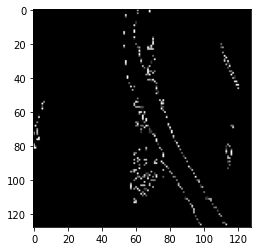

In [37]:
# plt.imshow(images[0][:,:,::-1])
plt.imshow(images[0])

In [12]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

In [96]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    Conv2D(48, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])

In [38]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1)
])
    

In [39]:
 # Modell für Regression kompilieren
# model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.compile(optimizer=Adam(learning_rate = 0.0001), loss='mean_squared_error', metrics=['mae'])

In [40]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 flatten_2 (Flatten)         (None, 100352)           

In [42]:
 history = model.fit(images, labels, epochs=50, validation_split=0.2, batch_size=64)

Epoch 1/50
5/5 [==============================] - 3s 684ms/step - loss: 444.2477 - mae: 16.6896 - val_loss: 523.1790 - val_mae: 18.6761
Epoch 2/50
5/5 [==============================] - 3s 656ms/step - loss: 436.8684 - mae: 16.6425 - val_loss: 521.6646 - val_mae: 18.7260
Epoch 3/50
5/5 [==============================] - 3s 650ms/step - loss: 426.9806 - mae: 16.4411 - val_loss: 514.2703 - val_mae: 18.4262
Epoch 4/50
5/5 [==============================] - 3s 609ms/step - loss: 426.0923 - mae: 16.3113 - val_loss: 511.4839 - val_mae: 18.4736
Epoch 5/50
5/5 [==============================] - 4s 747ms/step - loss: 421.8245 - mae: 16.4307 - val_loss: 510.7371 - val_mae: 18.4588
Epoch 6/50
5/5 [==============================] - 3s 650ms/step - loss: 410.0277 - mae: 16.0074 - val_loss: 504.7377 - val_mae: 18.2482
Epoch 7/50
5/5 [==============================] - 3s 653ms/step - loss: 404.9770 - mae: 15.9600 - val_loss: 511.0949 - val_mae: 18.4774
Epoch 8/50
5/5 [==============================] 

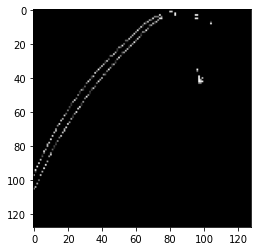

In [15]:
plt.imshow(images[100][:,:,::-1])

In [16]:
# Teil der Aufgabe - nicht löschen
def plot_images_from_array(x_train, labels, pred, grid=(15,15),figsize=(16,16)):
    """
    Plottet die ersten Images aus x_train
    labels: Array der labels
    """
    
    W_grid=grid[0]
    L_grid=grid[1]
    fig, axes = plt.subplots(L_grid, W_grid, figsize = figsize)
    axes = axes.ravel()      #ähnlich wie "flatten": https://numpy.org/doc/stable/reference/generated/numpy.ravel.html
    for i in np.arange(0, W_grid * L_grid): 
        index=i
        if index<len(x_train):
            axes[i].imshow(x_train[index][:,:,::-1])
            axes[i].set_title(str(int(labels[index])) + " -> " + str(int(pred[index])), fontsize = 16)
            axes[i].axis('off')
    plt.subplots_adjust(hspace=0.3)


In [31]:
y_pred = model.predict(images)
# val = model.predict(images[100])
# show_prediction(images[1], model)

In [19]:
y_pred[100]

array([96.1383], dtype=float32)

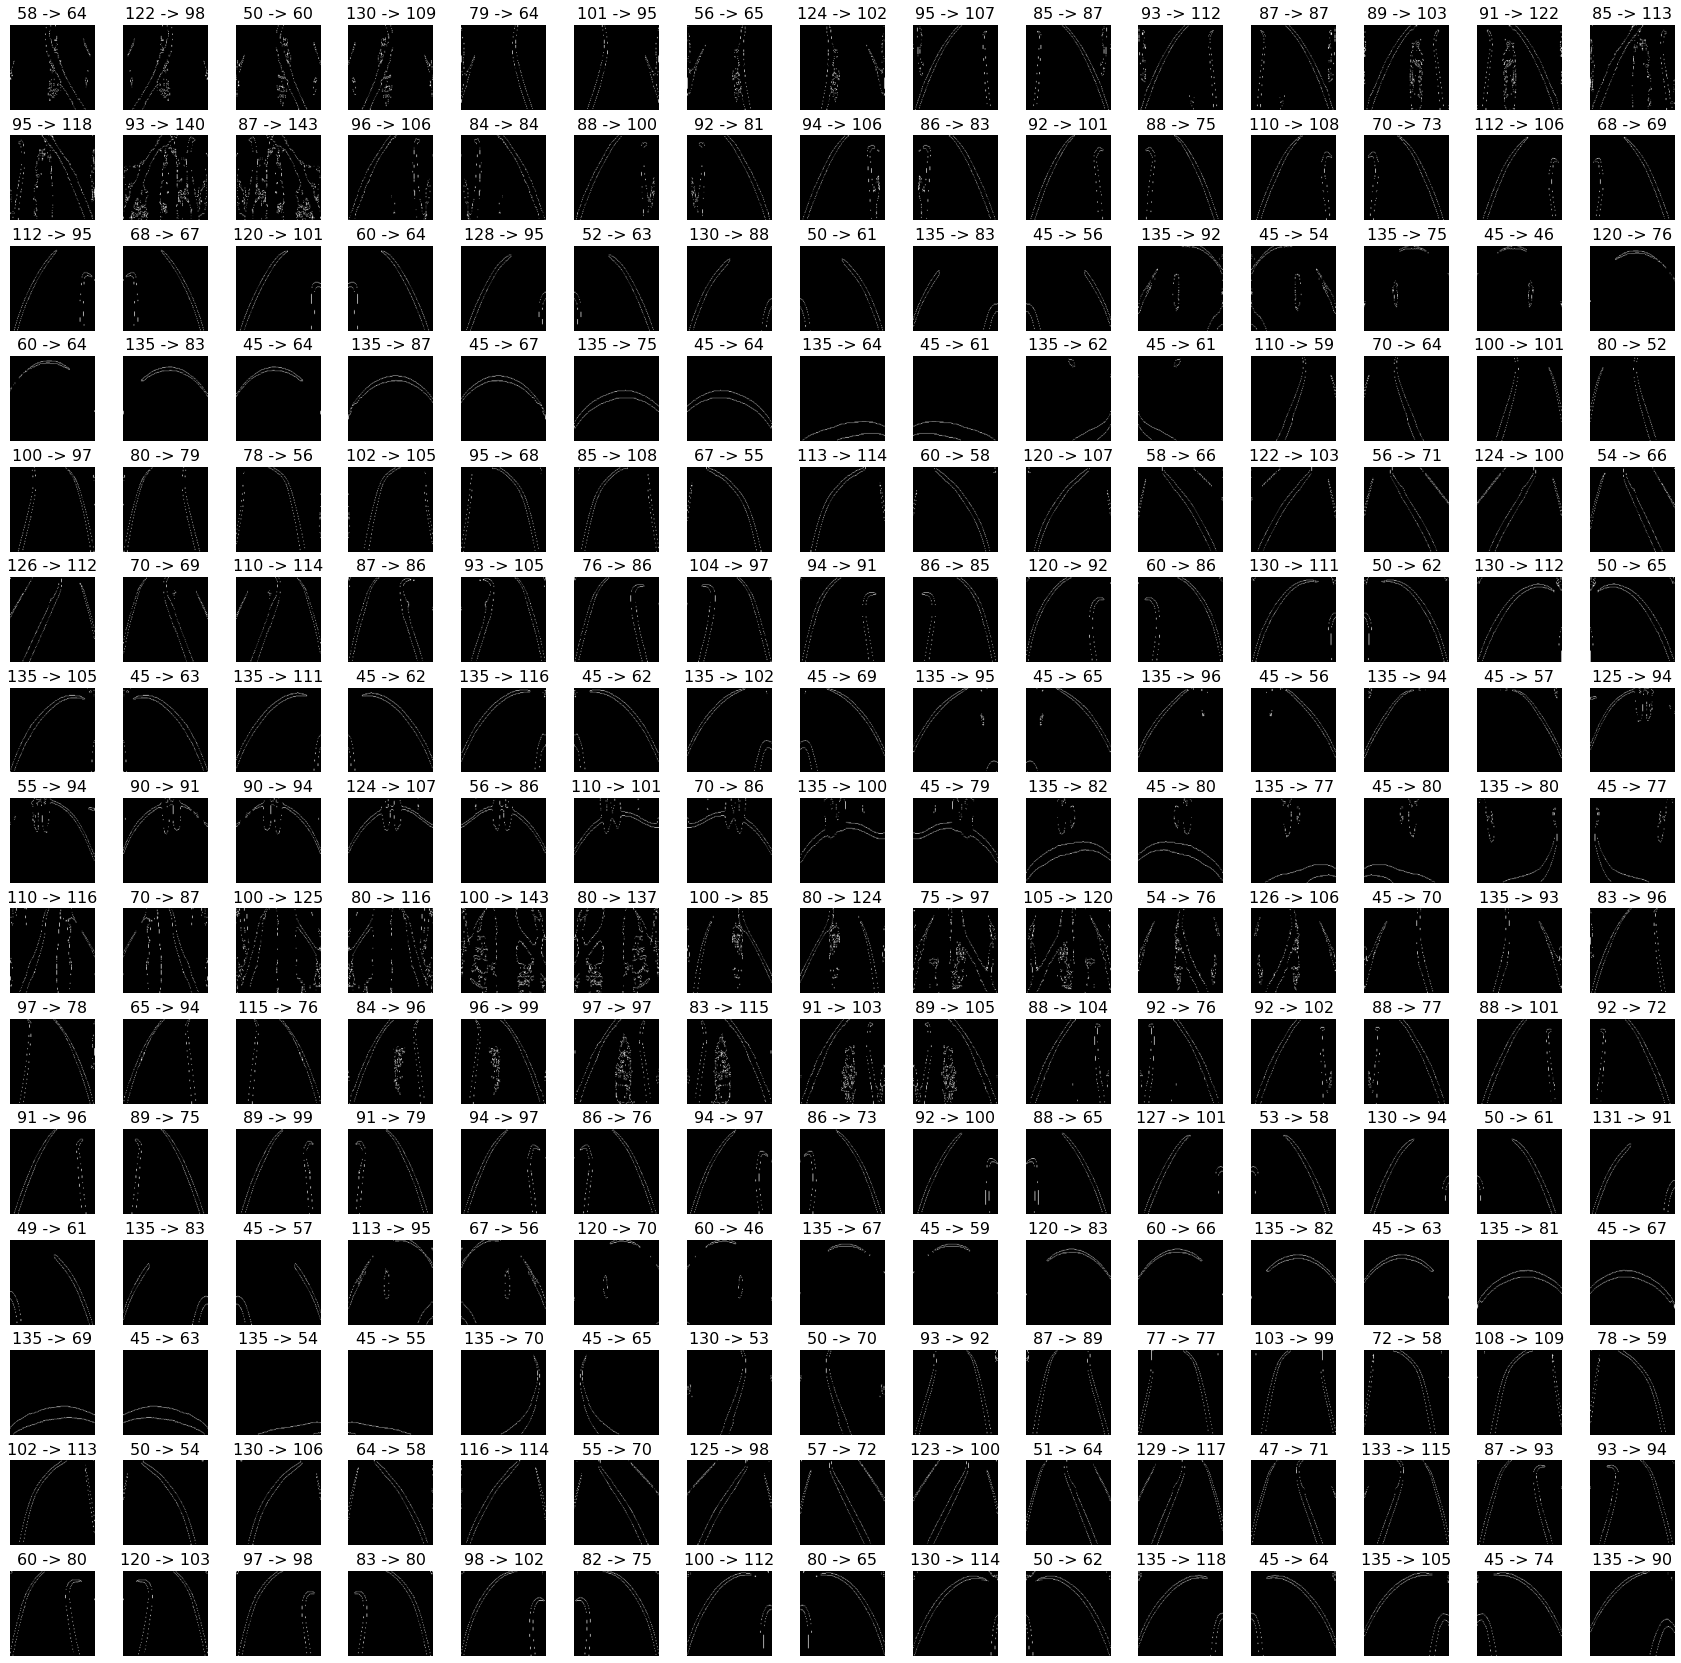

In [20]:
plot_images_from_array(images, labels, y_pred, grid=(15,15),figsize=(30,30))

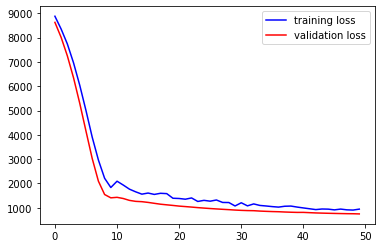

In [21]:
plot_train_history(history)

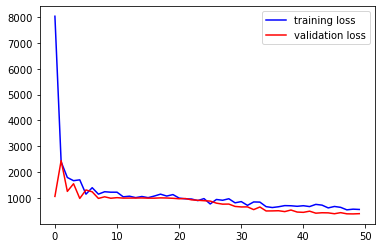

In [61]:
plot_train_history(history)

In [62]:
model.save('my_model.keras') #.keras

In [63]:
loaded_model = tf.keras.models.load_model('my_model.keras')

In [30]:
y_pred = loaded_model.predict(images)

NameError: name 'loaded_model' is not defined

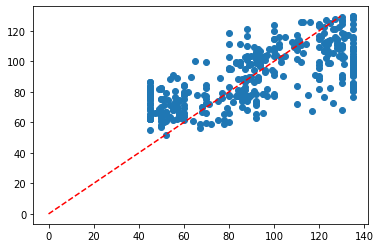

In [32]:
# idealerweise schwanken werte um die Winkelhalbierende
plt.scatter(labels, y_pred)
points = np.array([0, np.max(y_pred)])
plt.plot( points, points, 'r--', label='Random guess')

In [66]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

In [67]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\VWN7QRY\AppData\Local\Temp\tmpdzfgm93v\assets


INFO:tensorflow:Assets written to: C:\Users\VWN7QRY\AppData\Local\Temp\tmpdzfgm93v\assets


In [68]:
with open("TFLite_Modell.tflite", 'wb') as f:
    f.write(tflite_model)

In [69]:
np.__version__

'1.20.2'